In [1]:
import numpy as np
import skimage as ski
import matplotlib.pyplot as plt
from pathlib import Path
import tifffile
from stardist.models import StarDist2D
from stardist.plot import render_label
import preprocess_for_inference as prep

In [22]:
#load unseen stack 
Data=Path("../Data/Mixed") #whatever folder directly holds unseen stacks and corresponding h5 files

TARGET_SIZE=30 #should be the SAME as what you trained your model with, see preparing_training notebook

def prepare_stack(name):
    file_path = next(Data.rglob(f"{name}*.tiff"))
    h5_path= next(Data.rglob(f"{name}*.h5"))
    
    mag=prep.get_magnification(h5_path)
    stack=tifffile.imread(file_path)

    processed_stack,offsets=prep.apply_to_stack(stack,mag,TARGET_SIZE)
    #processing includes trimming, scaling and normalizing 
    return processed_stack

In [42]:
#prepict instances with original stardist model and fine-tuned one
stardist_model= StarDist2D.from_pretrained('2D_versatile_fluo')

name='v2'
basedir='./models'
my_model = StarDist2D(None, name=name, basedir=basedir) #pass config as None so does not initiate another model

Found model '2D_versatile_fluo' for 'StarDist2D'.
Loading network weights from 'weights_best.h5'.
Loading thresholds from 'thresholds.json'.
Using default values: prob_thresh=0.479071, nms_thresh=0.3.
Loading network weights from 'weights_best.h5'.
Loading thresholds from 'thresholds.json'.
Using default values: prob_thresh=0.497851, nms_thresh=0.3.


In [44]:
def show_both_labels(img):
    my_labels, _ = my_model.predict_instances(img)
    stardist_labels,_ = stardist_model.predict_instances(img) 
    
    fig, ax = plt.subplots(1, 3,figsize=(15,5))
    ax[0].imshow(img,cmap='gray')
    ax[0].set_title(f"Input Image")
    ax[1].imshow(render_label(stardist_labels, img=img, alpha=0.5, cmap='prism'))
    ax[1].set_title('Labels with original StarDist model')
    ax[2].imshow(render_label(my_labels, img=img, alpha=0.5, cmap='prism'))
    ax[2].set_title('Labels with fine-tuned model')
    plt.show()

In [60]:
#make tiff stacks of the processed images and the labels, to later feed to Trackmate !
def make_tiff_stacks(stack,name): #name is what you want your stacks to be called
    images_stack=np.stack(stack, axis=0)
    
    list_labels=[]
    for image in stack:
        labels,_=my_model.predict_instances(image) #make predictions for all frames
        list_labels.append(labels)
    label_stack = np.stack(list_labels, axis=0)
    label_stack = label_stack.astype(np.uint32)

    #save both
    tifffile.imwrite(f"{name}_images.tiff", images_stack)
    tifffile.imwrite(f"{name}_labels.tiff", label_stack)

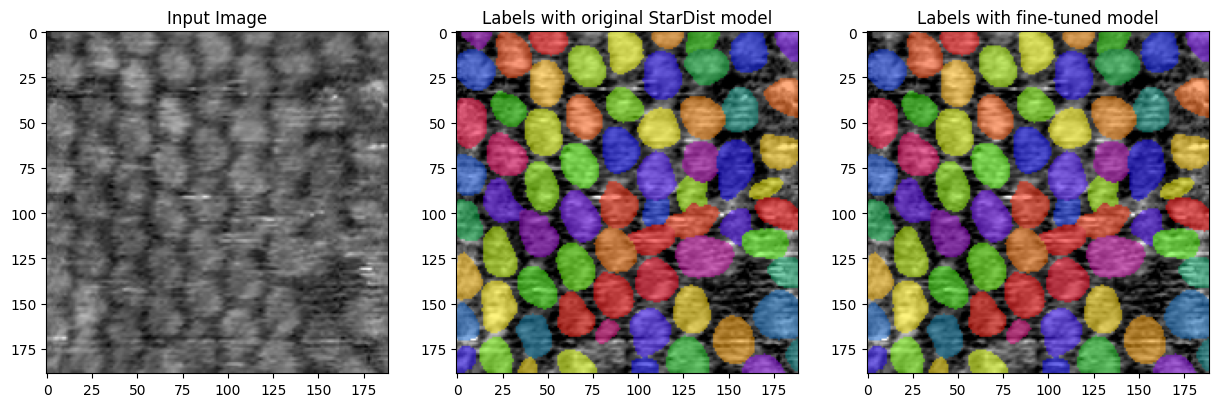

In [62]:
#example
stack=prepare_stack('FS_250903_007')
show_both_labels(stack[32])
make_tiff_stacks(stack,'FS_250903_007_v2')